# Figure 4 e — PTI-PAE vs CDR RMSD on the class I validation set

Per John's note: a version of the Figure 1 panel d scatter, restricted to the
**post-AF3-training class I cognate triads** (the same 16 triads that form the
Fig 4a validation set), with the x-axis swapped from **ipTM** to **PTI-PAE**.

This addresses the question "does the classifier feature (PTI-PAE) correlate
with structural accuracy on the held-out set?" — and is a tighter analogue of
the structural-quality-vs-confidence point made in Fig 1d, now using the
classifier's chosen feature.

## Data sources
- `../supplementaryTable3_updated.xlsx` — provides PTI-PAE for each triad
- `../Figure_1_structural_benchmarking/data/pdb_triad.af3_rmsd.parquet` —
  provides CDR RMSD (5 seeds available; default is the 5-seed median per the
  manuscript Methods; seed 0 also shown for reference)

The two tables are joined on `job_name`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

CI_BLUE = '#3a78b8'

# Load both sources
st3  = pd.read_excel('../supplementaryTable3_updated.xlsx')
af3p = pd.read_parquet('../Figure_1_structural_benchmarking/data/pdb_triad.af3_rmsd.parquet')

# 'PTI-PAE' refers to the raw mean_p_tcr_interface_pae; we plot 31 - PTI-PAE
st3['pti_pae_31'] = 31 - st3['mean_p_tcr_interface_pae']

# Filter to class I cognate triads in supp table 3 (16 triads = Fig 4a validation set)
val = st3[(st3['mhc_class'] == 'I') & (st3['cognate'] == True)].copy()

# Merge in CDR RMSDs (5 seeds) from the AF3 parquet
seed_cols = [f'cdr_rmsd_af3_{i}' for i in range(5)]
val = val.merge(
    af3p[['job_name', 'pdb', 'pdb_date', 'replication'] + seed_cols],
    on='job_name', how='left'
)

# Compute 5-seed median (manuscript default)
val['cdr_rmsd_5seed_median'] = val[seed_cols].median(axis=1)

# Confirm all 16 are post-AF3-cutoff (replication==False)
assert (val['replication'] == False).all(), 'Expected all class I cognates to be post-AF3 cutoff'

print(f'Validation set: {len(val)} triads, all post-AF3-cutoff class I cognates')
print()
print(val[['pdb', 'peptide', 'pti_pae_31', 'cdr_rmsd_af3_0', 'cdr_rmsd_5seed_median']]
      .sort_values('pti_pae_31').to_string(index=False))

Validation set: 16 triads, all post-AF3-cutoff class I cognates

 pdb    peptide  pti_pae_31  cdr_rmsd_af3_0  cdr_rmsd_5seed_median
8es9 GVYDGREHTV       16.78       17.912052              17.014524
8wte  VVGAVGVGK       22.33        2.855849               2.855849
8gom  RLQSLQTYV       22.63       22.805682               4.390197
8f5a TSTLQEQIGW       22.93        3.458406               3.181110
8ye4  NYNYLYRLF       23.59        4.381153               4.381153
8i5c  VVGAVGVGK       23.86        4.542551               2.198972
8wul  VVGAVGVGK       24.46        3.093435               3.429995
8i5d  VVGAVGVGK       24.88        1.886481               1.886481
8gon  RLQSLQIYV       25.05       23.857141               5.063500
7q99 NLSALGIFST       27.93        1.305301               1.731691
8en8  LPFDKSTIM       28.26        1.302022               1.302022
7q9a LLLGIGILVL       28.32        1.755917               1.755917
7q9b EAAGIGILTV       28.35        7.372325               7.5429

## PTI-PAE vs CDR RMSD scatter (5-seed median)

Saved: Fig4_e_PTIPAE_vs_RMSD_5seed_median.png


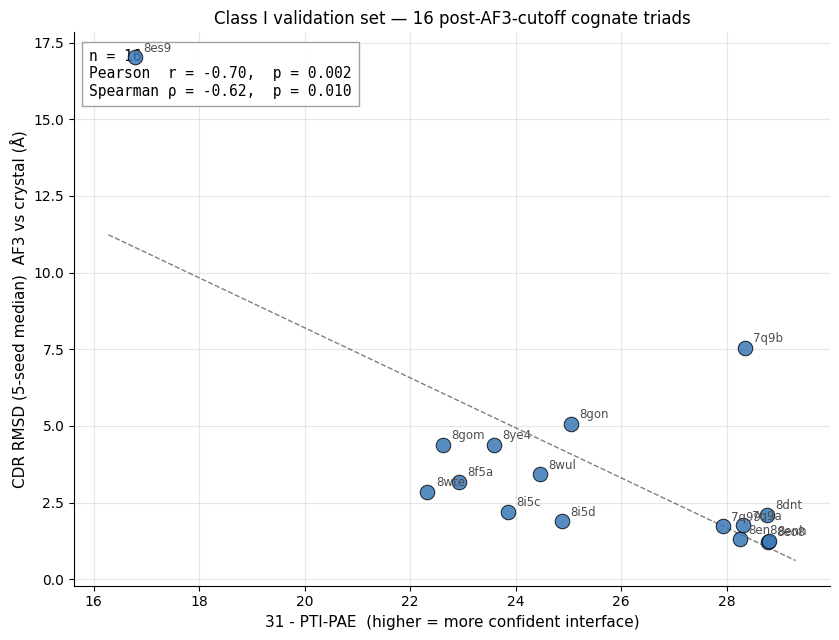

In [2]:
def plot_scatter(df, rmsd_col, rmsd_label, out_path):
    fig, ax = plt.subplots(figsize=(8.5, 6.5))

    x = df['pti_pae_31'].values
    y = df[rmsd_col].values
    ax.scatter(x, y, s=110, color=CI_BLUE,
               edgecolors='black', linewidths=0.7, alpha=0.85, zorder=4)

    # PDB labels on each point
    for _, r in df.iterrows():
        ax.annotate(r['pdb'], (r['pti_pae_31'], r[rmsd_col]),
                    xytext=(6, 4), textcoords='offset points',
                    fontsize=8.5, color='0.3', zorder=5)

    # Linear fit
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min() - 0.5, x.max() + 0.5, 50)
    ax.plot(xs, slope * xs + intercept, 'k--', alpha=0.5, lw=1, zorder=2)

    # Correlations
    r_p, p_p   = pearsonr(x, y)
    r_s, p_s   = spearmanr(x, y)
    ax.text(0.02, 0.97,
            f'n = {len(df)}\n'
            f'Pearson  r = {r_p:+.2f},  p = {p_p:.3f}\n'
            f'Spearman ρ = {r_s:+.2f},  p = {p_s:.3f}',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=10.5, family='monospace',
            bbox=dict(facecolor='white', edgecolor='0.6', pad=5, alpha=0.92))

    ax.set_xlabel('31 - PTI-PAE  (higher = more confident interface)', fontsize=11)
    ax.set_ylabel(f'{rmsd_label}  AF3 vs crystal (Å)', fontsize=11)
    ax.set_title('Class I validation set — 16 post-AF3-cutoff cognate triads', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {out_path}')
    plt.show()


# Default: 5-seed median (per manuscript Methods)
plot_scatter(val, 'cdr_rmsd_5seed_median',
             'CDR RMSD (5-seed median)',
             'Fig4_e_PTIPAE_vs_RMSD_5seed_median.png')

## Also show seed-0 version for reference

Seed-0 CDR RMSDs include the catastrophic reverse-dock failures (8gom, 8gon
at ~23 Å) that are recovered by other seeds in the 5-seed median. The seed-0
version makes the "PTI-PAE flags rigid-body failures" point most clearly.

Saved: Fig4_e_PTIPAE_vs_RMSD_seed0.png


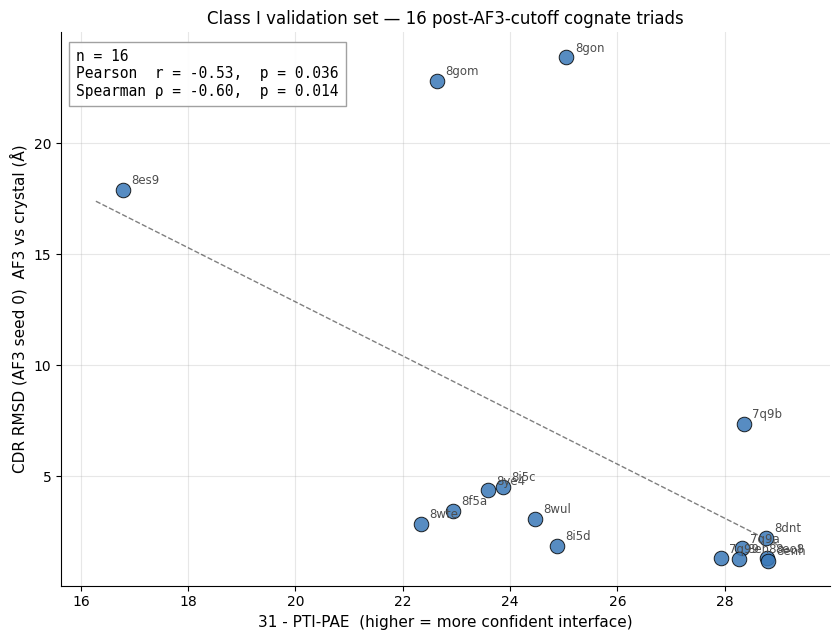

In [3]:
plot_scatter(val, 'cdr_rmsd_af3_0',
             'CDR RMSD (AF3 seed 0)',
             'Fig4_e_PTIPAE_vs_RMSD_seed0.png')

## Interpretation

PTI-PAE on the held-out class I validation set is strongly correlated with
CDR RMSD — confirming the Fig 1d observation that AF3's interface confidence
predicts structural accuracy, now extended to the classifier's chosen feature
(PTI-PAE) on triads AF3 has never seen.

The handful of reverse-dock failures (8gom, 8gon) sit at high RMSD AND
moderate-to-low PTI-PAE, supporting the manuscript's argument that PTI-PAE
flags rigid-body failures even when local CDR conformations remain accurate
(see also `reviewer_responses/structural_analysis/` for the Ramachandran TV
analysis showing local CDR conformations are preserved in those failures).